# Implicit FWI with multiresolution hash encoding (Marmousi)

Reproduces the Marmousi example of *Accelerating High Resolution Implicit Full Waveform
Inversion* (Shaowen Wang and Tariq Alkhalifah, *Geophysics*), first presented as the EAGE
abstract *Multiresolution hash encoding for high resolution implicit full waveform
inversion* ([10.3997/2214-4609.202510109](https://doi.org/10.3997/2214-4609.202510109)).
The stand-alone reproduction package is
[DeepWave-KAUST/ifwi-pub](https://github.com/DeepWave-KAUST/ifwi-pub). Here the velocity
network is sweep-nn's `VelocityINR` and the wave equation is sweep's compiled acoustic
solver.

Three inversions from the same smoothed starting model:

1. **Conventional FWI**: Adam on the grid velocity.
2. **Implicit FWI**: `vp = vp_init + vp_std · SIREN(z, x)`, a 6-layer SIREN.
3. **Implicit FWI + hash encoding**: an Instant-NGP multiresolution hash grid in front of a
   1-layer SIREN. The hash grid carries the fine detail a plain SIREN is slow to fit.

**Needs** a CUDA GPU and `pip install sweep-nn sweep-solver`. Run it from this directory:
it imports `ifwi_models.py`, which holds the two velocity models. The full 200
iterations take about 2 minutes on an RTX 6000 Ada; `IFWI_EPOCHS=40` gives a quick
check.

## Setup: models, acquisition, solver and observed data

In [1]:
import os

# ---------------- Marmousi / hash-encoding configuration (paper Table 2) ----------------
DH, DT = 25.0, 0.002
SPATIAL_ORDER, ABCN = 8, 30               # 8th-order space, 2nd-order time
NT, FM, DELAY = 2500, 8.0, 0.5            # 5.0 s record, 8 Hz Ricker
SRC_INTERVAL, REC_INTERVAL = 2, 1         # a source every 50 m, a receiver at every surface point
BATCH = 8                                 # shots per iteration, drawn at random
SEED = 19491001

CONV_LR = 20.0                            # conventional FWI: Adam on the grid (m/s)
NN_LR, LR_DECAY = 1e-4, 0.9995            # implicit FWI: Adam on the weights, exponential decay
HIDDEN, OMEGA = 128, 30.0                 # SIREN width and sine frequency
STD2, LAYERS2 = 370.0, 6                  # experiment 2: SIREN only
STD3, LAYERS3 = 3700.0, 1                 # experiment 3: hash grid + a 1-layer SIREN
HASH = dict(hash_levels=4, hash_features_per_level=1, hash_log2_size=18,
            hash_base_resolution=64, hash_finest_resolution=256)
EXP3_LABEL = "iFWI + hash encoding"

EPOCHS = int(os.environ.get("IFWI_EPOCHS", "200"))
CONV_EPOCHS = EPOCHS                      # conventional FWI is stable on this model

In [2]:
import time
import numpy as np, torch, matplotlib.pyplot as plt
from sweep.equations import Acoustic
from sweep.propagator.torch import PropTorch
from sweep_nn import VelocityINR
import ifwi_models          # the velocity models, embedded: nothing to download

dev = "cuda"
torch.manual_seed(SEED); np.random.seed(SEED)
print("GPU:", torch.cuda.get_device_name(0))

vp_true, vp_smooth = ifwi_models.marmousi("true"), ifwi_models.marmousi("smooth")
shape = vp_true.shape; nz, nx = shape
vp_true_t, vp_smooth_t = (torch.tensor(m, device=dev) for m in (vp_true, vp_smooth))
print(f"Marmousi: shape={shape}, dh={DH} m, vp in [{vp_true.min():.0f}, {vp_true.max():.0f}] m/s")

t = np.arange(NT, dtype=np.float32) * DT - DELAY                    # Ricker wavelet
a = (np.pi * FM * t) ** 2
wavelet = ((1.0 - 2.0 * a) * np.exp(-a)).astype(np.float32)
sx = np.arange(0, nx, SRC_INTERVAL)                                 # surface survey, grid points [x, z]
sources = np.stack([sx, np.zeros_like(sx)], 1).astype(np.int64)
rx = np.arange(0, nx, REC_INTERVAL)
receivers = np.repeat(np.stack([rx, np.zeros_like(rx)], 1)[None], len(sources), 0).astype(np.int64)
print(f"{len(sources)} shots, {receivers.shape[1]} receivers, nt={NT}, epochs={EPOCHS}")

solver = PropTorch(Acoustic(spatial_order=SPATIAL_ORDER, device=dev), shape=shape, dh=DH, dt=DT,
                   abcn=ABCN, free_surface=False, source_type=["h1"], receiver_type=["h1"],
                   impl="c")
print("solver impl =", solver.impl, "| gradient memory:", solver.memory_strategy)

t0 = time.time()
with torch.no_grad():                                               # observed data from the true model
    observed = torch.cat([solver(wavelet, sources[i:i + 16], receivers[i:i + 16], models=[vp_true_t])
                          for i in range(0, len(sources), 16)])
print(f"observed data {tuple(observed.shape)} generated in {time.time() - t0:.1f} s")

GPU: NVIDIA RTX 6000 Ada Generation
Marmousi: shape=(141, 341), dh=25.0 m, vp in [1028, 4700] m/s
171 shots, 341 receivers, nt=2500, epochs=200
solver impl = c | gradient memory: boundary


observed data (171, 2500, 341, 1) generated in 0.7 s


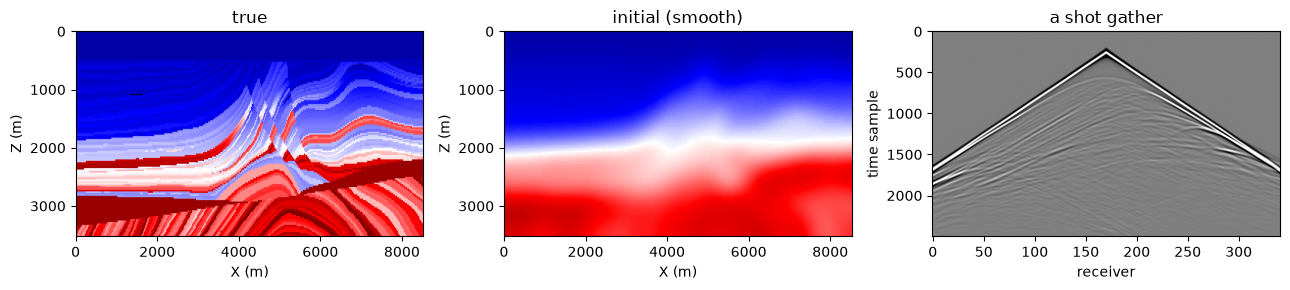

In [3]:
fig, ax = plt.subplots(1, 3, figsize=(13, 3))
ext = [0, nx*DH, nz*DH, 0]
vk = dict(cmap="seismic", aspect="auto", extent=ext, vmin=vp_true.min(), vmax=vp_true.max())
for a, m, t in zip(ax[:2], [vp_true, vp_smooth], ["true", "initial (smooth)"]):
    im = a.imshow(m, **vk); a.set_title(t); a.set_xlabel("X (m)"); a.set_ylabel("Z (m)")
g = observed[len(sources)//2, :, :, 0].detach().cpu().numpy()
v = np.percentile(np.abs(g), 98)
ax[2].imshow(g, cmap="gray", aspect="auto", vmin=-v, vmax=v)
ax[2].set_title("a shot gather"); ax[2].set_xlabel("receiver"); ax[2].set_ylabel("time sample")
plt.tight_layout(); plt.show()

## The inversion loop

One loop drives all three experiments: `model_fn()` returns the velocity grid and Adam
steps on `params`, the grid itself for conventional FWI, the network weights for
implicit FWI. Every experiment draws the same random mini-batches (`SEED`), so they
differ only in what is optimized.

(The Overthrust notebook also uses `use_ph=True`.) With it, the gradient of the velocity grid is divided by the summed
illumination `Σ sqrt(s·r)` before it is back-propagated into the weights. The
source and receiver illumination `s`, `r` come straight off the solver
(`solver.source_illumination` / `solver.receiver_illumination`) after each shot's
backward pass. It is an extra grid pass, so it is on only while `use_ph` is.

In [4]:
def run_inversion(model_fn, params, *, epochs, lr, lr_decay=1.0, use_ph=False, eps_ill=1e-11,
                  log_every=50):
    solver.compute_illumination = use_ph
    rng = np.random.default_rng(SEED)
    opt = torch.optim.Adam(params, lr=lr, eps=1e-22)
    sched = torch.optim.lr_scheduler.ExponentialLR(opt, lr_decay) if lr_decay < 1.0 else None
    hist = {"loss": [], "rmse": []}
    for ep in range(epochs):
        idx = rng.choice(len(sources), size=min(BATCH, len(sources)), replace=False)
        opt.zero_grad(set_to_none=True)
        vp = model_fn()
        if use_ph:          # shot by shot, so that each shot brings its own illumination
            g_vp, scale, loss = torch.zeros_like(vp), torch.zeros_like(vp), 0.0
            for s in idx:
                syn = solver(wavelet, sources[s:s + 1], receivers[s:s + 1], models=[vp])
                loss_s = (syn - observed[s:s + 1]).pow(2).mean()
                g_vp += torch.autograd.grad(loss_s, vp, retain_graph=True)[0]
                scale += torch.sqrt(solver.source_illumination * solver.receiver_illumination)
                loss += float(loss_s.detach()) / len(idx)
            grads = torch.autograd.grad(vp, params, grad_outputs=g_vp / (scale + eps_ill))
            for p, g in zip(params, grads):
                p.grad = g
        else:
            syn = solver(wavelet, sources[idx], receivers[idx], models=[vp])
            loss_t = (syn - observed[idx]).pow(2).mean()
            loss_t.backward()
            loss = float(loss_t.detach())
        opt.step()
        if sched is not None:
            sched.step()
        with torch.no_grad():
            rmse = float(torch.sqrt(torch.mean((model_fn() - vp_true_t) ** 2)))
        hist["loss"].append(loss); hist["rmse"].append(rmse)
        if ep % log_every == 0 or ep == epochs - 1:
            print(f"  iter {ep:4d}  loss {loss:.4e}  model RMSE {rmse:6.1f} m/s", flush=True)
    with torch.no_grad():
        hist["vp"] = model_fn().cpu().numpy()
    return hist

In [5]:
print("Experiment 1/3 - conventional FWI (optimize the grid velocity directly)")
t0 = time.time()
vp_grid = vp_smooth_t.clone().requires_grad_(True)
h_conv = run_inversion(lambda: vp_grid, [vp_grid], epochs=CONV_EPOCHS, lr=CONV_LR)
print(f"  {time.time() - t0:.0f} s")

Experiment 1/3 - conventional FWI (optimize the grid velocity directly)


  iter    0  loss 3.8401e-02  model RMSE  372.9 m/s


  iter   50  loss 4.2743e-03  model RMSE  349.2 m/s


  iter  100  loss 7.8846e-04  model RMSE  321.2 m/s


  iter  150  loss 2.8548e-04  model RMSE  305.2 m/s


  iter  199  loss 3.0162e-04  model RMSE  297.6 m/s


  29 s


In [6]:
print("Experiment 2/3 - implicit FWI (SIREN)")
t0 = time.time()
torch.manual_seed(SEED)
net = VelocityINR(vp_smooth_t, vp_std=STD2, hidden_features=HIDDEN, hidden_layers=LAYERS2,
                  first_omega0=OMEGA, hidden_omega0=OMEGA, use_hash_encoding=False).to(dev)
print(f"  {sum(p.numel() for p in net.parameters()):,} network weights for {nz * nx:,} grid cells")
h_ifwi = run_inversion(net, list(net.parameters()), epochs=EPOCHS, lr=NN_LR, lr_decay=LR_DECAY)
print(f"  {time.time() - t0:.0f} s")

Experiment 2/3 - implicit FWI (SIREN)
  98,688 network weights for 48,081 grid cells


  iter    0  loss 3.2925e-02  model RMSE  370.2 m/s


  iter   50  loss 7.2706e-03  model RMSE  375.3 m/s


  iter  100  loss 4.5631e-03  model RMSE  377.7 m/s


  iter  150  loss 3.4844e-03  model RMSE  379.4 m/s


  iter  199  loss 3.5380e-03  model RMSE  380.2 m/s


  30 s


In [7]:
print("Experiment 3/3 - implicit FWI + multiresolution hash encoding")
t0 = time.time()
torch.manual_seed(SEED)
net = VelocityINR(vp_smooth_t, vp_std=STD3, hidden_features=HIDDEN, hidden_layers=LAYERS3,
                  first_omega0=OMEGA, hidden_omega0=OMEGA, use_hash_encoding=True, **HASH).to(dev)
n_hash = net.encoder.latents.numel()
print(f"  {n_hash:,} hash-table entries + {sum(p.numel() for p in net.mlp.parameters()):,} SIREN weights")
h3 = run_inversion(net, list(net.parameters()), epochs=EPOCHS, lr=NN_LR, lr_decay=LR_DECAY)
print(f"  {time.time() - t0:.0f} s")

Experiment 3/3 - implicit FWI + multiresolution hash encoding
  106,808 hash-table entries + 17,024 SIREN weights


  iter    0  loss 3.8388e-02  model RMSE  369.6 m/s


  iter   50  loss 7.8371e-03  model RMSE  364.2 m/s


  iter  100  loss 1.6051e-03  model RMSE  344.4 m/s


  iter  150  loss 3.8161e-04  model RMSE  324.9 m/s


  iter  199  loss 1.5821e-04  model RMSE  311.1 m/s


  28 s


## Comparison of the three inversions (manuscript Figure 7)

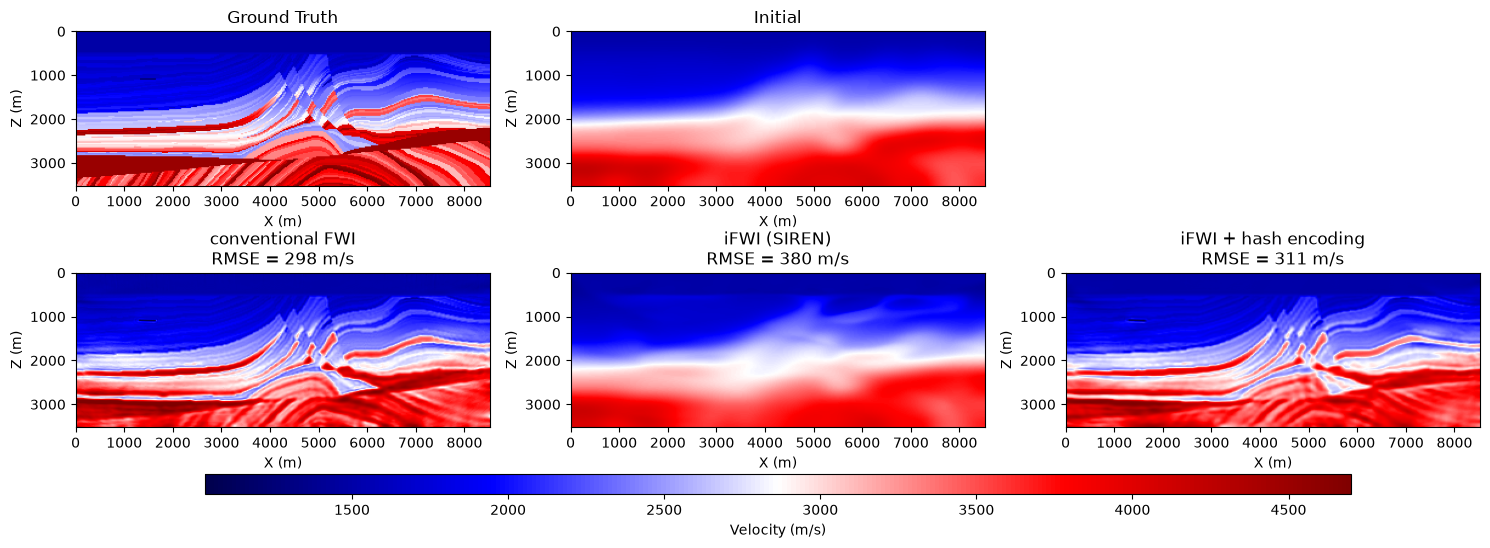

final model RMSE (m/s): {'conventional FWI': 298, 'iFWI (SIREN)': 380, 'iFWI + hash encoding': 311}


In [8]:
runs = [("conventional FWI", h_conv), ("iFWI (SIREN)", h_ifwi), (EXP3_LABEL, h3)]
rmse = lambda a: float(np.sqrt(np.mean((a - vp_true) ** 2)))
ext = [0, nx*DH, nz*DH, 0]
vk = dict(cmap="seismic", aspect="auto", extent=ext, vmin=vp_true.min(), vmax=vp_true.max())

fig, axes = plt.subplots(2, 3, figsize=(15, 6.0))
for a, (name, m) in zip(axes[0], [("Ground Truth", vp_true), ("Initial", vp_smooth)]):
    im = a.imshow(m, **vk); a.set_title(name)
    a.set_xlabel("X (m)"); a.set_ylabel("Z (m)")
axes[0, 2].axis("off")
for a, (name, h) in zip(axes[1], runs):                                          # the three inversions
    r = rmse(h["vp"])
    im = a.imshow(np.nan_to_num(h["vp"], nan=float(vp_true.mean())), **vk)
    a.set_title(f"{name}\nRMSE = {r:.0f} m/s" if np.isfinite(r) else f"{name}\n(diverged)")
    a.set_xlabel("X (m)"); a.set_ylabel("Z (m)")
plt.tight_layout(rect=[0, 0.07, 1, 1])
cb = fig.colorbar(im, ax=axes, orientation="horizontal", fraction=0.045, pad=0.10, aspect=55)
cb.set_label("Velocity (m/s)")
plt.show()

print("final model RMSE (m/s):", {name: (round(rmse(h["vp"])) if np.isfinite(rmse(h["vp"])) else "NaN") for name, h in runs})

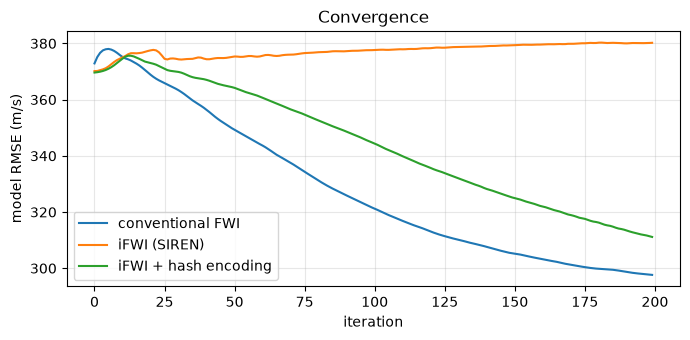

In [9]:
fig, ax = plt.subplots(figsize=(7, 3.5))
for name, h in runs:
    ax.plot(h["rmse"], label=name)
ax.set_xlabel("iteration"); ax.set_ylabel("model RMSE (m/s)"); ax.set_title("Convergence")
ax.grid(alpha=0.3); ax.legend()
plt.tight_layout(); plt.show()

## Vertical profiles (manuscript Figure 8)

Profiles through the true, initial and three inverted models at x = 3.0 and 5.0 km.

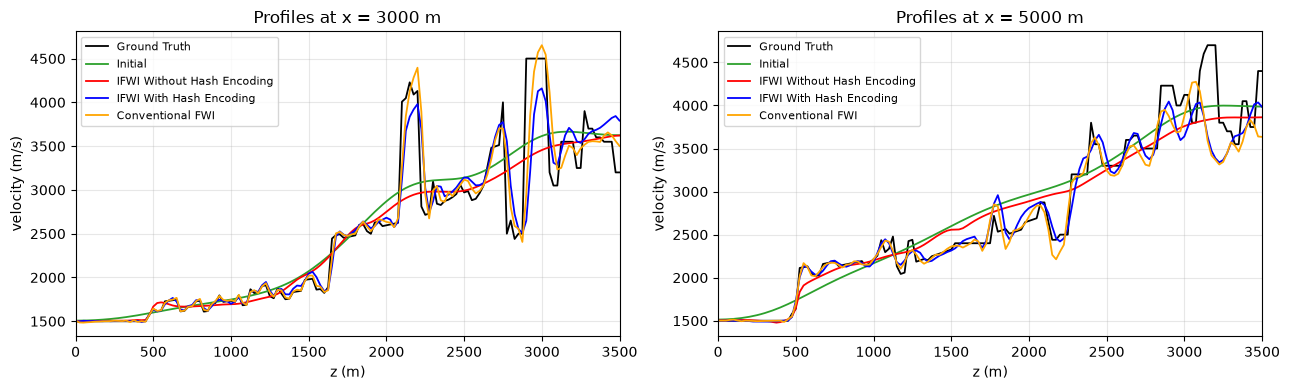

In [10]:
series = [("Ground Truth", vp_true, "k"),
          ("Initial", vp_smooth, "tab:green"),
          ("IFWI Without Hash Encoding", h_ifwi["vp"], "red"),
          ("IFWI With Hash Encoding", h3["vp"], "blue"),
          ("Conventional FWI", h_conv["vp"], "orange")]
z = np.arange(nz) * DH

fig, ax = plt.subplots(1, 2, figsize=(13, 4))
for a, xm in zip(ax, [3000.0, 5000.0]):
    ix = int(round(xm / DH))
    for name, m, c in series:
        a.plot(z, np.asarray(m)[:, ix], c, lw=1.3, label=name)
    a.set_title(f"Profiles at x = {xm:.0f} m")
    a.set_xlabel("z (m)"); a.set_ylabel("velocity (m/s)")
    a.set_xlim(0, z[-1]); a.grid(alpha=0.3); a.legend(fontsize=8)
plt.tight_layout(); plt.show()

## Result

Final model RMSE on an RTX 6000 Ada with sweep-solver 0.3.5: **298 / 380 / 311 m/s** for
conventional FWI / implicit FWI / implicit FWI + hash encoding. The paper reports
298 / 371 / 310.

Conventional FWI matches the paper exactly, since it involves no network; the implicit
runs start from different random weights than the paper's code, which moves them by a
few m/s. A plain SIREN only smooths the starting model. With the hash grid in front, a
one-layer SIREN recovers the fine layering and the faults, at the resolution of
conventional FWI.